<a href="https://colab.research.google.com/github/barney-rai/asl-recognition/blob/main/ASL_Final_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn

from tqdm import tqdm
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
from torch.utils.data import random_split

In [2]:
#Check GPU, in Colab should be cuda
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [3]:
#import ASL images
from google.colab import drive

drive.mount("/content/drive")

BASE_DIR = "/content/drive/MyDrive/ASL_Project"

print(os.listdir(BASE_DIR), len(BASE_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['A', 'B', 'E', 'F', 'D', 'C', 'G', 'H', 'M', 'N', 'L', 'J', 'K', 'I', 'Q', 'S', 'P', 'T', 'R', 'U', 'O', 'nothing', 'Z', 'X', 'space', 'W', 'del', 'V', 'Y', 'asl_weights.pth'] 34


In [4]:
#class names
classes = sorted([
    folder
    for folder in os.listdir(BASE_DIR)
    if os.path.isdir(os.path.join(BASE_DIR, folder))
])

print(classes)
print("Number of classes:", len(classes))

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Number of classes: 29


In [5]:
#a =0, b=1...z=25
class_to_idx = {
    class_name: i
    for i, class_name in enumerate(classes)
}

print(class_to_idx)

{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16, 'R': 17, 'S': 18, 'T': 19, 'U': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24, 'Z': 25, 'del': 26, 'nothing': 27, 'space': 28}


In [6]:
images = []
labels = []

In [7]:
#process all images (grayscale, resize, store image and label)
for class_name in classes:

    class_dir = os.path.join(BASE_DIR, class_name)
    label = class_to_idx[class_name]

    files = os.listdir(class_dir)

    print(f"\nProcessing {class_name}: {len(files)} images")

    for filename in tqdm(files):

        image_path = os.path.join(class_dir, filename)

        img = cv2.imread(image_path)

        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        resized = cv2.resize(gray, (64, 64))

        images.append(resized)
        labels.append(label)


Processing A: 3000 images


100%|██████████| 3000/3000 [00:10<00:00, 294.12it/s]



Processing B: 3000 images


100%|██████████| 3000/3000 [00:59<00:00, 50.65it/s] 



Processing C: 3000 images


...

100%|██████████| 3000/3000 [00:57<00:00, 52.34it/s] 



Processing nothing: 3000 images


100%|██████████| 3000/3000 [01:00<00:00, 49.80it/s] 



Processing space: 3000 images


100%|██████████| 3000/3000 [00:57<00:00, 52.42it/s] 


In [8]:
X = np.array(images)
y = np.array(labels)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (87090, 64, 64)
y shape: (87090,)


In [9]:
X = X.astype(np.float32) / 255.0
print("Minimum:", X.min())
print("Maximum:", X.max())

Minimum: 0.0
Maximum: 1.0


In [10]:
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

print("X:", X_tensor.shape)
print("y:", y_tensor.shape)

X: torch.Size([87090, 64, 64])
y: torch.Size([87090])


In [11]:
dataset = TensorDataset(X_tensor, y_tensor)

print("Total images:", len(dataset))

Total images: 87090


In [12]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Training images: 69672
Validation images: 17418


In [13]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [14]:
class ASLCNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [15]:
model = ASLCNN(num_classes=29)

model = model.to(device)

print(model)

ASLCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=29, bias=True)
  )
)


In [16]:
#prediton + label = loss
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [17]:
#tests
#test batch
images, labels = next(iter(train_loader))

images = images.unsqueeze(1)

images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

#loss check
loss = criterion(outputs, labels)

print("Loss:", loss.item())

#test backprop
optimizer.zero_grad()

loss.backward()

optimizer.step()

print("Training step successful!")


Input shape: torch.Size([32, 1, 64, 64])
Output shape: torch.Size([32, 29])
Loss: 3.3374342918395996
Training step successful!


In [18]:
num_epochs = 5

for epoch in range(num_epochs):

    # -------------------
    # Training
    # -------------------
    model.train()

    total_train_loss = 0

    for images, labels in train_loader:

        images = images.unsqueeze(1)

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    # -------------------
    # Validation
    # -------------------
    model.eval()

    total_val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.unsqueeze(1)

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            total_val_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_val_loss = total_val_loss / len(val_loader)

    accuracy = 100 * correct / total

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Accuracy: {accuracy:.2f}%"
    )

Epoch 1/5 | Train Loss: 1.2429 | Val Loss: 0.4887 | Val Accuracy: 84.23%
Epoch 2/5 | Train Loss: 0.3088 | Val Loss: 0.2366 | Val Accuracy: 92.30%
Epoch 3/5 | Train Loss: 0.1718 | Val Loss: 0.1499 | Val Accuracy: 95.56%
Epoch 4/5 | Train Loss: 0.1181 | Val Loss: 0.1187 | Val Accuracy: 96.31%
Epoch 5/5 | Train Loss: 0.0904 | Val Loss: 0.0935 | Val Accuracy: 97.30%


In [ ]:
print(model)
print(type(model))

In [ ]:
torch.save(model.state_dict(),"asl_weights.pth")

In [ ]:
import os

print(os.path.exists("asl_weights.pth"))
print(os.path.getsize("asl_weights.pth"))

In [ ]:
import shutil

shutil.copy(
    "asl_weights.pth",
    "/content/drive/MyDrive/ASL_Project/asl_weights.pth"
)

In [ ]:
import os

print(
    os.path.exists(
        "/content/drive/MyDrive/ASL_Project/asl_weights.pth"
    )
)

In [ ]:
model_loaded = ASLCNN(num_classes=29)

In [ ]:
model_loaded.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/ASL_Project/asl_weights.pth",
        map_location=device
    )
)

In [ ]:
model_loaded = model_loaded.to(device)

In [ ]:
model_loaded.eval()

In [ ]:
image, label = val_dataset[0]
image = image.unsqueeze(0).unsqueeze(0)
image = image.to(device)
with torch.no_grad():
    output = model_loaded(image)
prediction = output.argmax(dim=1).item()
print("Actual class:", label.item())
print("Predicted class:", prediction)

In [29]:
#calculate validation accuracy on untrained images
correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.unsqueeze(1)

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total

print("Correct:", correct)
print("Total:", total)
print(f"Validation Accuracy: {accuracy:.2f}%")

Correct: 16947
Total: 17418
Validation Accuracy: 97.30%


In [30]:
all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.unsqueeze(1)

        images = images.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())


In [31]:
all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)
print("Predictions:", all_predictions.shape)
print("Labels:", all_labels.shape)

Predictions: (17418,)
Labels: (17418,)


In [32]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm)

[[621  10   1   3   5   0   0   0   0   0   0   0   0   0  13   0   0   0
    0   1   0   0   0   0   0   1   0   0   0]
 [  0 592   0   2   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   2   0   0   0   0   0   0]
 [  0   0 603   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   1 603   0   5   0   0   1   0   0   0   0   0   2   0   0   0
    0   0   0   1   0   0   0   0   0   0   0]
 [  4  49   0   9 474   1   3   0   3   0   0   0   0   0   0   0   0   0
    2   0   0   3   0   0   0   0   0   0   0]
 [  0   0   0   1   0 615   0   0   0   0   0   0   0   0   1   0   0   0
    0   0   0   0   3   0   0   0   0   0   1]
 [  0   0   0   0   0   0 605   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0  41 547   0   1   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   

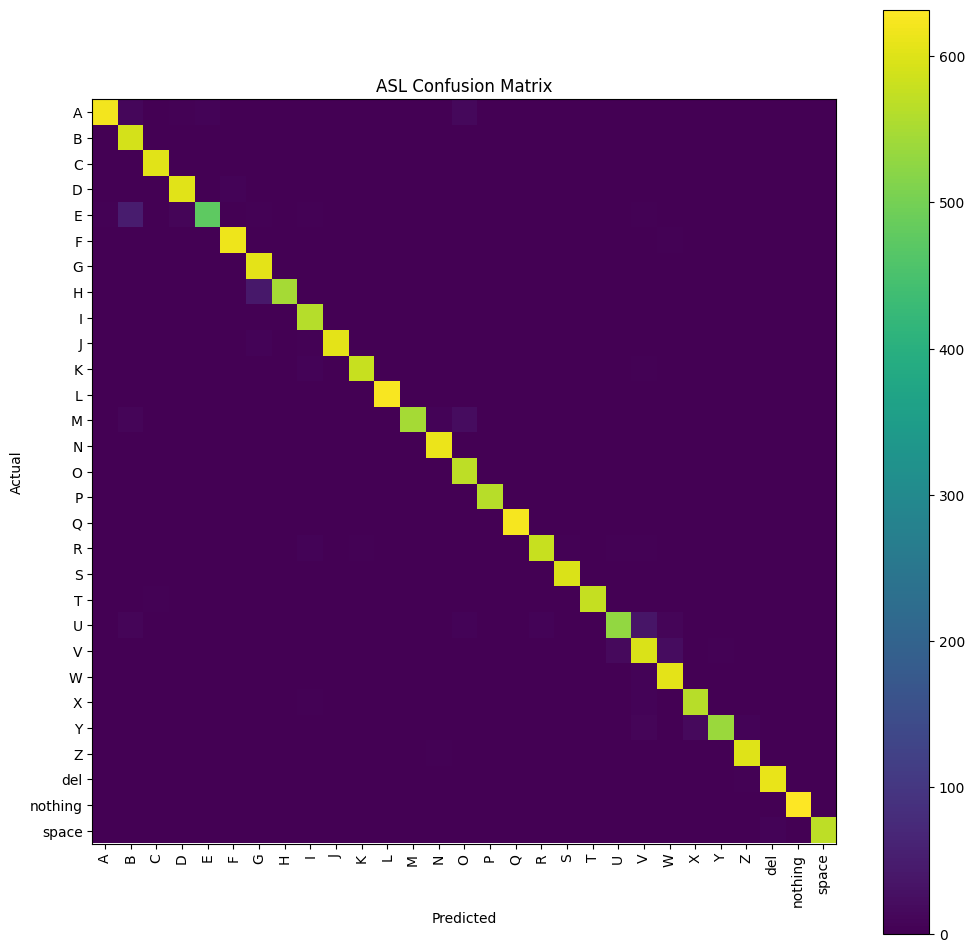

In [33]:
#note 8/29 - E has a 86 percent accuary, which is lowest
#difficulty distinguishing certain visually similar gestures, particularly E, U, V, H, M, and Y.
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))

plt.imshow(cm)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ASL Confusion Matrix")

plt.xticks(
    range(len(classes)),
    classes,
    rotation=90
)

plt.yticks(
    range(len(classes)),
    classes
)

plt.colorbar()

plt.show()

In [34]:
for i, class_name in enumerate(classes):

    class_total = np.sum(all_labels == i)

    class_correct = np.sum(
        (all_labels == i) &
        (all_predictions == i)
    )

    class_accuracy = 100 * class_correct / class_total

    print(
        f"{class_name}: "
        f"{class_accuracy:.2f}%"
    )

A: 94.81%
B: 99.33%
C: 99.83%
D: 98.37%
E: 86.50%
F: 99.03%
G: 100.00%
H: 92.87%
I: 99.65%
J: 98.37%
K: 97.80%
L: 99.68%
M: 92.70%
N: 99.67%
O: 99.65%
P: 99.47%
Q: 99.68%
R: 96.19%
S: 99.17%
T: 99.14%
U: 89.21%
V: 92.98%
W: 98.70%
X: 98.09%
Y: 93.57%
Z: 98.69%
del: 99.19%
nothing: 99.84%
space: 98.45%


In [35]:
incorrect_indices = np.where(
    all_predictions != all_labels
)[0]

print("Incorrect predictions:", len(incorrect_indices))

Incorrect predictions: 471


Actual: R
Predicted: S


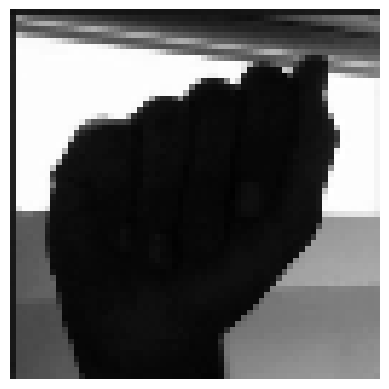

In [36]:
idx = incorrect_indices[0]

image = X[idx]

actual = classes[all_labels[idx]]
predicted = classes[all_predictions[idx]]

print("Actual:", actual)
print("Predicted:", predicted)

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()